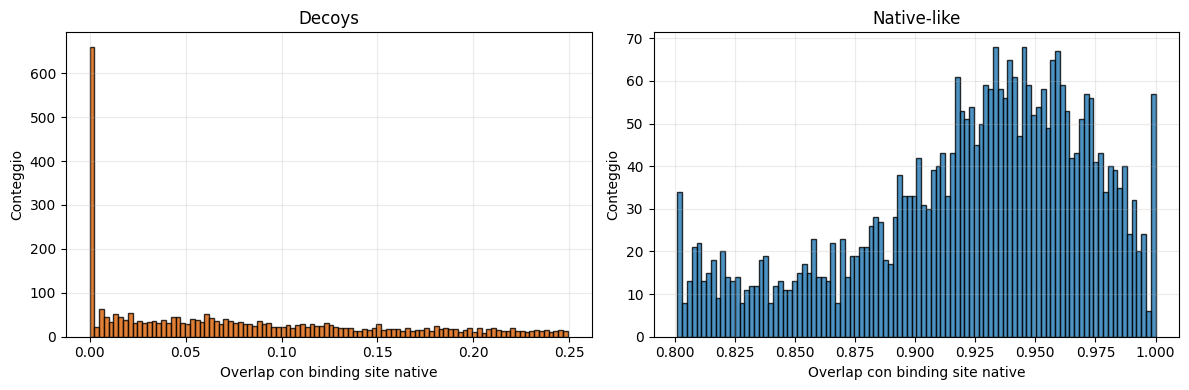

In [5]:
import json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

json_paths = {
    "decoys": Path("input_files/Jac_idx_decoy.json"),
    "native_like": Path("input_files/Jac_idx_native_like.json"),
}

with json_paths["decoys"].open("r", encoding="utf-8") as handle:
    decoy_values = json.load(handle)

with json_paths["native_like"].open("r", encoding="utf-8") as handle:
    native_like_values = json.load(handle)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(decoy_values, bins=100, color="#d95f02", alpha=0.8, edgecolor="black")
axes[0].set_title("Decoys")
axes[0].set_xlabel("Overlap con binding site native")
axes[0].set_ylabel("Conteggio")
axes[0].grid(alpha=0.25)

axes[1].hist(native_like_values, bins=100, color="#1f77b4", alpha=0.8, edgecolor="black")
axes[1].set_title("Native-like")
axes[1].set_xlabel("Overlap con binding site native")
axes[1].set_ylabel("Conteggio")
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

nativelike_raw_df = pd.read_csv('output_files/nativelike/nativelike.csv')
decoys_raw_df = pd.read_csv('output_files/decoys/decoys.csv')
all_nativelike_df = pd.read_csv('output_files/native/all_native.csv')
native_like_jindex_df = pd.read_csv('output_files/nativelike/nativelike_j_index.csv')
native_like_jindex_df['complex name'] = native_like_jindex_df['complex name'].astype(str)
native_like_jindex_df['J index'] = pd.to_numeric(native_like_jindex_df['J index'], errors='coerce')

N_RINGS = 10
RDF_DETECTOR_PREFIXES = ('physical_ring', 'zernike_ring', 'roughness_ring')
RDF_COL_PATTERNS = (
    'physical_ring{rid}_mean',
    'physical_ring{rid}_uncertainty',
    'zernike_ring{rid}_mean',
    'zernike_ring{rid}_uncertainty',
    'roughness_ring{rid}',
)


def prepare_datasets_for_jmax(jmax):
    nativelike_df = nativelike_raw_df.assign(
        _complex_key=nativelike_raw_df['complex_name'].astype(str).str.replace('-', '_', regex=False)
    ).merge(
        native_like_jindex_df.rename(columns={'complex name': '_complex_key', 'J index': 'j_index'}),
        on='_complex_key',
        how='inner',
    )
    nativelike_df = nativelike_df.loc[nativelike_df['j_index'] <= float(jmax)].copy()
    nativelike_df['complex_prefix'] = nativelike_df['complex_name'].astype(str).str.split('-').str[0].str[:4]

    decoys_df = decoys_raw_df.copy()
    decoys_df['complex_prefix'] = decoys_df['complex_name'].astype(str).str.split('-').str[0].str[:4]

    common_complexes = sorted(set(nativelike_df['complex_prefix'].dropna()).intersection(set(decoys_df['complex_prefix'].dropna())))
    nativelike_df = nativelike_df.loc[nativelike_df['complex_prefix'].isin(common_complexes)].copy()
    decoys_df = decoys_df.loc[decoys_df['complex_prefix'].isin(common_complexes)].copy()

    if len(nativelike_df) != len(decoys_df):
        raise ValueError(f'Filtered datasets have different sizes at jmax={jmax}: {len(nativelike_df)} vs {len(decoys_df)}')

    nativelike_df = nativelike_df.drop(columns=['_complex_key', 'j_index', 'complex_prefix'])
    decoys_df = decoys_df.drop(columns=['complex_prefix'])
    return nativelike_df, decoys_df, len(common_complexes)


def add_ring_mean_columns(df, radius_col='radius', n_rings=N_RINGS):
    df = df.copy()
    radius_values = pd.to_numeric(df[radius_col], errors='coerce')
    for ring_id in range(1, n_rings + 1):
        df[f'ring{ring_id}_mean_A'] = radius_values * (ring_id - 0.5) / n_rings
    return df


def build_feature_table(df, use_radius_limit=False, radius_limit=20.0):
    feature_columns = ['complex_name', 'dataset_label', 'physical_mean', 'roughness']
    if df.empty:
        return pd.DataFrame(columns=feature_columns)

    grouped_cols = ['radius'] + [f'physical_ring{i}_mean' for i in range(1, 11)] + [f'roughness_ring{i}' for i in range(1, 11)]
    grouped = df.groupby(['complex_name', 'dataset_label'], as_index=False)[grouped_cols].mean()
    rows = []

    for _, row in grouped.iterrows():
        radius = pd.to_numeric(pd.Series([row['radius']]), errors='coerce').iloc[0]
        if not np.isfinite(radius) or radius <= 0:
            continue

        if use_radius_limit:
            valid_rings = [rid for rid in range(1, N_RINGS + 1) if radius * rid / float(N_RINGS) <= float(radius_limit)]
        else:
            valid_rings = list(range(1, N_RINGS + 1))

        physical_values = []
        roughness_values = []
        for rid in valid_rings:
            physical_value = pd.to_numeric(pd.Series([row[f'physical_ring{rid}_mean']]), errors='coerce').iloc[0]
            roughness_value = pd.to_numeric(pd.Series([row[f'roughness_ring{rid}']]), errors='coerce').iloc[0]
            if np.isfinite(physical_value):
                physical_values.append(float(physical_value))
            if np.isfinite(roughness_value):
                roughness_values.append(float(roughness_value))

        if not physical_values or not roughness_values:
            continue

        rows.append({
            'complex_name': row['complex_name'],
            'dataset_label': row['dataset_label'],
            'physical_mean': float(np.mean(physical_values)),
            'roughness': float(np.mean(roughness_values)),
        })

    if not rows:
        return pd.DataFrame(columns=feature_columns)
    return pd.DataFrame(rows, columns=feature_columns)


def evaluate_separation(feature_df):
    required_columns = ['physical_mean', 'roughness', 'dataset_label']
    if feature_df.empty or not set(required_columns).issubset(feature_df.columns):
        return {
            'n': int(feature_df.shape[0]),
            'auc_mean': np.nan,
            'auc_std': np.nan,
            'accuracy_mean': np.nan,
            'accuracy_std': np.nan,
        }

    clean_df = feature_df.dropna(subset=required_columns).copy()
    if clean_df.empty or clean_df['dataset_label'].nunique() < 2:
        return {
            'n': int(clean_df.shape[0]),
            'auc_mean': np.nan,
            'auc_std': np.nan,
            'accuracy_mean': np.nan,
            'accuracy_std': np.nan,
        }

    X = clean_df[['physical_mean', 'roughness']].to_numpy(dtype=float)
    y = (clean_df['dataset_label'] == 'decoy').astype(int).to_numpy()
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
    auc_scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc')
    acc_scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')

    return {
        'n': int(clean_df.shape[0]),
        'auc_mean': float(np.mean(auc_scores)),
        'auc_std': float(np.std(auc_scores)),
        'accuracy_mean': float(np.mean(acc_scores)),
        'accuracy_std': float(np.std(acc_scores)),
    }


print('native_like_jindex rows:', native_like_jindex_df.shape[0])
print('nativelike_raw_df:', nativelike_raw_df.shape)
print('decoys_raw_df:', decoys_raw_df.shape)
print('all_nativelike_df:', all_nativelike_df.shape)

native_like_jindex rows: 3256
nativelike_raw_df: (3726, 63)
decoys_raw_df: (3134, 63)
all_nativelike_df: (3731, 63)


In [ ]:
jmax_values = np.linspace(0.8, 1.0, 200, endpoint=True)
sweep_rows = []

for jmax in jmax_values:
    nativelike_jmax_df, decoys_jmax_df, n_common = prepare_datasets_for_jmax(float(jmax))

    nativelike_jmax_df = add_ring_mean_columns(nativelike_jmax_df)
    decoys_jmax_df = add_ring_mean_columns(decoys_jmax_df)

    nativelike_labeled = nativelike_jmax_df.copy()
    nativelike_labeled['dataset_label'] = 'nativelike'
    decoys_labeled = decoys_jmax_df.copy()
    decoys_labeled['dataset_label'] = 'decoy'

    combined_df = pd.concat([nativelike_labeled, decoys_labeled], ignore_index=True)
    feature_all_rings = build_feature_table(combined_df, use_radius_limit=False)
    feature_radius_20 = build_feature_table(combined_df, use_radius_limit=True, radius_limit=20.0)

    stats_all_rings = evaluate_separation(feature_all_rings)
    stats_radius_20 = evaluate_separation(feature_radius_20)

    sweep_rows.append({
        'jmax': float(jmax),
        'n_complexes': int(n_common),
        'auc_all_rings': stats_all_rings['auc_mean'],
        'auc_all_rings_std': stats_all_rings['auc_std'],
        'accuracy_all_rings': stats_all_rings['accuracy_mean'],
        'accuracy_all_rings_std': stats_all_rings['accuracy_std'],
        'auc_radius_20': stats_radius_20['auc_mean'],
        'auc_radius_20_std': stats_radius_20['auc_std'],
        'accuracy_radius_20': stats_radius_20['accuracy_mean'],
        'accuracy_radius_20_std': stats_radius_20['accuracy_std'],
    })

sweep_df = pd.DataFrame(sweep_rows)
print(sweep_df[['jmax', 'n_complexes', 'auc_all_rings', 'accuracy_all_rings', 'auc_radius_20', 'accuracy_radius_20']].to_string(index=False))

def plot_metric_with_complex_marginal(data, metric_all_col, metric_radius_col, title, y_label, color_all, color_radius):
    fig, (ax_top, ax_main) = plt.subplots(
        2,
        1,
        figsize=(12, 7),
        sharex=True,
        gridspec_kw={'height_ratios': [1, 4], 'hspace': 0.18},
    )

    ax_top.bar(data['jmax'], data['n_complexes'], width=0.008, color='#4c78a8', alpha=0.85, edgecolor='black')
    ax_top.set_title('Numero di complessi per jmax', pad=10)
    ax_top.set_ylabel('Numero di complessi')
    ax_top.grid(alpha=0.25)

    sns.lineplot(data=data, x='jmax', y=metric_all_col, marker='o', ax=ax_main, color=color_all, label='Tutti gli anelli')
    sns.lineplot(data=data, x='jmax', y=metric_radius_col, marker='o', ax=ax_main, color=color_radius, label='Raggio <= 20 A')
    ax_main.set_title(title, pad=12)
    ax_main.set_xlabel('jmax')
    ax_main.set_ylabel(y_label)
    ax_main.grid(alpha=0.25)
    ax_main.legend()

    fig.subplots_adjust(top=0.92)
    plt.show()

plot_metric_with_complex_marginal(
    sweep_df,
    metric_all_col='auc_all_rings',
    metric_radius_col='auc_radius_20',
    title='AUC vs jmax',
    y_label='AUC',
    color_all='#1f77b4',
    color_radius='#d95f02',
)

plot_metric_with_complex_marginal(
    sweep_df,
    metric_all_col='accuracy_all_rings',
    metric_radius_col='accuracy_radius_20',
    title='Accuracy vs jmax',
    y_label='Accuracy',
    color_all='#1f77b4',
    color_radius='#d95f02',
)

print('min complexes:', int(sweep_df['n_complexes'].min()))
print('max complexes:', int(sweep_df['n_complexes'].max()))
print('best AUC all rings at jmax =', float(sweep_df.loc[sweep_df['auc_all_rings'].idxmax(), 'jmax']))
print('best accuracy all rings at jmax =', float(sweep_df.loc[sweep_df['accuracy_all_rings'].idxmax(), 'jmax']))

KeyboardInterrupt: 